# Descriptive statistics — gas dataset consistency

Goal: visually check that `y_gas_mw` behaves as expected against each block of Table 1 explanatory variables (thermal, calendar, seasonal) before moving on to modeling. 9 charts, one per key relationship.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

df = pd.read_parquet("../data/processed/dataset_final.parquet")

local = df.index.tz_convert("Europe/Paris")
df["month"] = local.month
df["hour"] = local.hour
df["dow"] = local.dayofweek  # 0=Monday
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df["dow_name"] = pd.Categorical.from_codes(df["dow"], categories=dow_labels, ordered=True)

season_map = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer", 9: "Autumn", 10: "Autumn", 11: "Autumn"}
df["season"] = df["month"].map(season_map)

print(f"{len(df):,} lignes | {df.index.min()} -> {df.index.max()}")
df[["y_gas_mw", "temp_raw_c", "X1_heating", "X2_smo_heating"]].describe().round(1)

73,750 lignes | 2018-01-01 00:00:00+00:00 -> 2026-05-31 21:00:00+00:00


,y_gas_mw,temp_raw_c,X1_heating,X2_smo_heating
count,73639.0,73750.0,73750.0,73750.0
mean,47707.3,13.0,4.0,3.8
std,26468.7,6.9,4.4,4.1
min,2506.0,-7.0,0.0,0.0
25%,25702.0,7.8,0.0,0.0
50%,39299.0,12.4,2.6,2.4
75%,66658.5,18.0,7.2,6.9
max,158464.0,36.2,22.0,17.4


## 1. Consumption distribution (y)
Expected bimodal: a low, tight "summer/non-heating" mode and a high, spread-out "winter/heating" mode (temperature sensitivity).

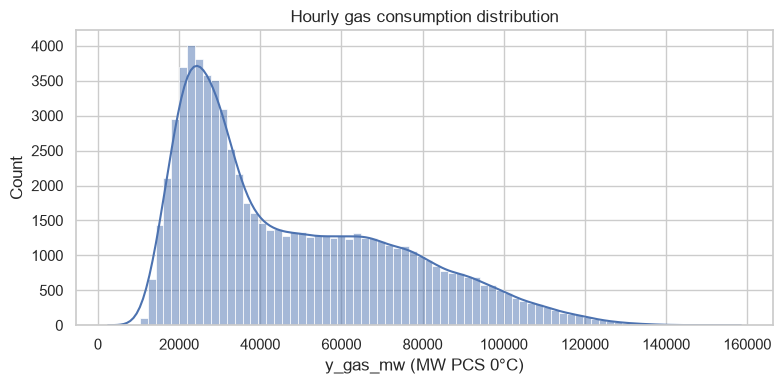

count     73639.0
mean      47707.0
std       26469.0
min        2506.0
25%       25702.0
50%       39299.0
75%       66658.0
max      158464.0
Name: y_gas_mw, dtype: float64


In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["y_gas_mw"].dropna(), bins=80, kde=True, ax=ax, color="#4C72B0")
ax.set_xlabel("y_gas_mw (MW PCS 0°C)")
ax.set_title("Hourly gas consumption distribution")
plt.tight_layout()
plt.show()

print(df["y_gas_mw"].describe().round(0))

## 2. Time series (daily average, 2018-2026)
Should show clear annual seasonality (winter peaks, summer troughs) and no suspicious level break.

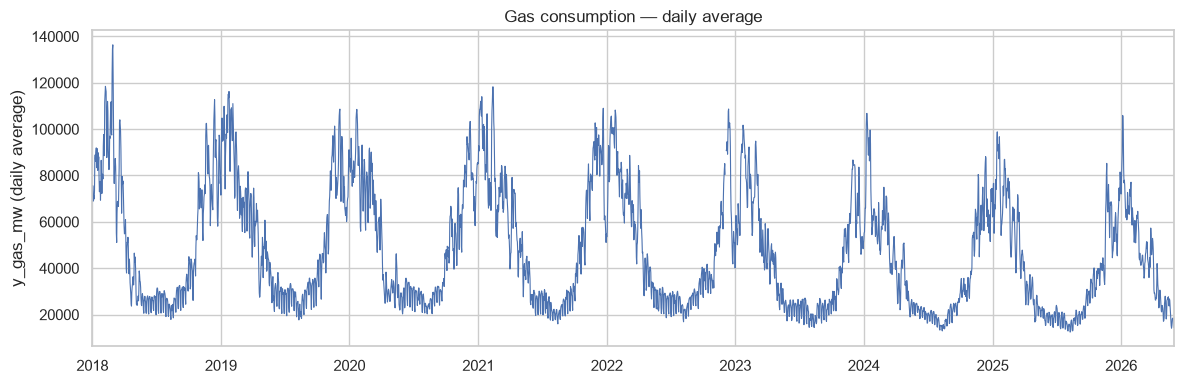

In [3]:
daily = df["y_gas_mw"].resample("D").mean()

fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax, linewidth=0.8, color="#4C72B0")
ax.set_ylabel("y_gas_mw (daily average)")
ax.set_title("Gas consumption — daily average")
plt.tight_layout()
plt.show()

## 3. Temperature ↔ consumption relationship (by season)
Expected relationship: decreasing and globally convex below ~15°C (heating threshold), flat above. A 5,000-point sample is used for readability.

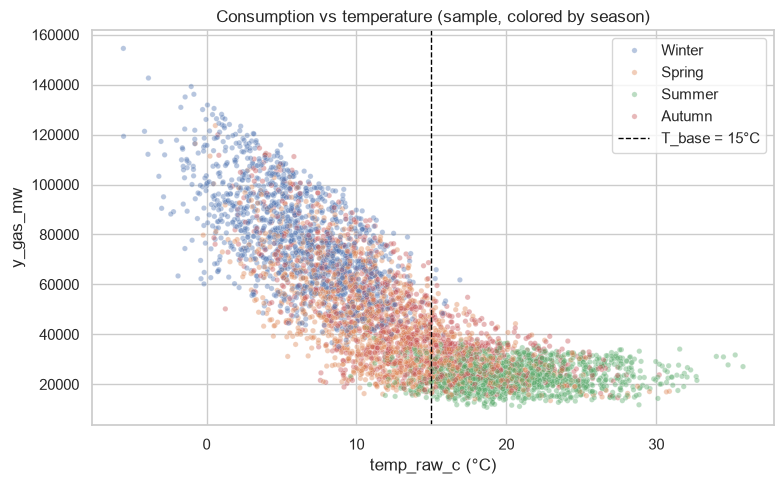

Pearson correlation(y, temp_raw_c) = -0.797


In [4]:
sample = df.dropna(subset=["y_gas_mw", "temp_raw_c"]).sample(5000, random_state=0)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=sample, x="temp_raw_c", y="y_gas_mw", hue="season", hue_order=["Winter", "Spring", "Summer", "Autumn"],
                 alpha=0.4, s=15, ax=ax, palette="deep")
ax.axvline(15, color="black", linestyle="--", linewidth=1, label="T_base = 15°C")
ax.set_xlabel("temp_raw_c (°C)")
ax.set_ylabel("y_gas_mw")
ax.set_title("Consumption vs temperature (sample, colored by season)")
ax.legend(title="")
plt.tight_layout()
plt.show()

print("Pearson correlation(y, temp_raw_c) =", round(df[["y_gas_mw", "temp_raw_c"]].corr().iloc[0, 1], 3))

## 4. Thermal block: immediate reaction (X1) vs heating inertia (X2)
Both should relate positively to y. X2 (smoothed) should show a more regular/less noisy relationship than X1 (raw).

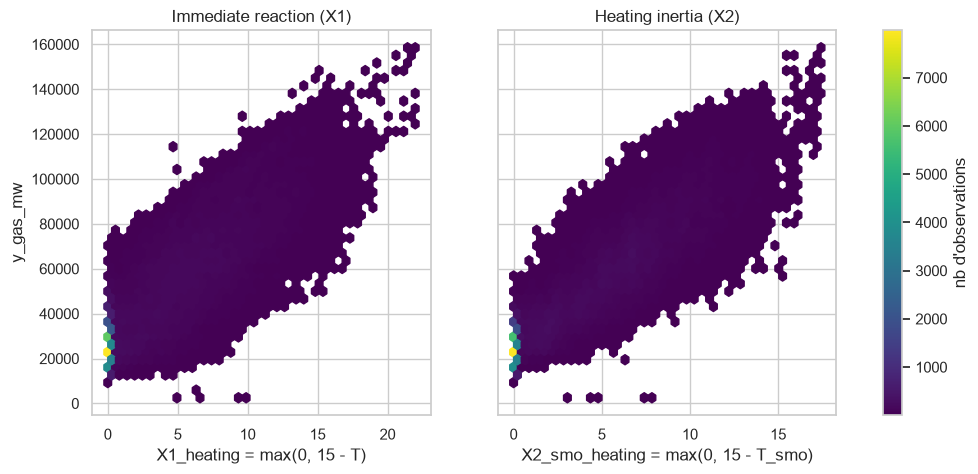

corr(y, X1_heating) = 0.851
corr(y, X2_smo_heating) = 0.904


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

hb1 = axes[0].hexbin(df["X1_heating"], df["y_gas_mw"], gridsize=40, cmap="viridis", mincnt=1)
axes[0].set_xlabel("X1_heating = max(0, 15 - T)")
axes[0].set_ylabel("y_gas_mw")
axes[0].set_title("Immediate reaction (X1)")

hb2 = axes[1].hexbin(df["X2_smo_heating"], df["y_gas_mw"], gridsize=40, cmap="viridis", mincnt=1)
axes[1].set_xlabel("X2_smo_heating = max(0, 15 - T_smo)")
axes[1].set_title("Heating inertia (X2)")

fig.colorbar(hb2, ax=axes, label="nb d'observations")
plt.show()

print("corr(y, X1_heating) =", round(df[["y_gas_mw", "X1_heating"]].corr().iloc[0, 1], 3))
print("corr(y, X2_smo_heating) =", round(df[["y_gas_mw", "X2_smo_heating"]].corr().iloc[0, 1], 3))

## 5. Calendar effects (public holidays / school breaks / end-of-year period)
Expected: lower consumption during `is_off_peak_period` and `is_end_of_year` (industrial closures), at comparable temperature.

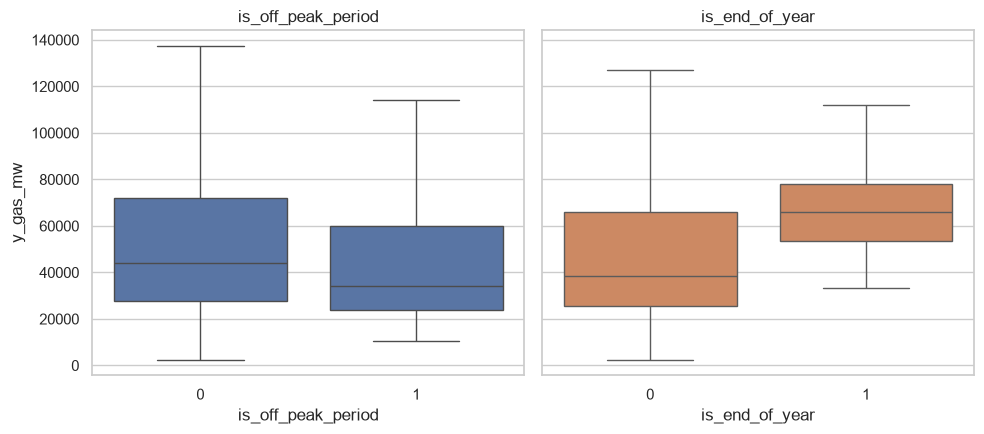

is_off_peak_period
0    51346.0
1    43183.0
Name: y_gas_mw, dtype: float64
is_end_of_year
0    47306.0
1    66538.0
Name: y_gas_mw, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
sns.boxplot(data=df, x="is_off_peak_period", y="y_gas_mw", ax=axes[0], showfliers=False, color="#4C72B0")
axes[0].set_title("is_off_peak_period")
sns.boxplot(data=df, x="is_end_of_year", y="y_gas_mw", ax=axes[1], showfliers=False, color="#DD8452")
axes[1].set_title("is_end_of_year")
plt.tight_layout()
plt.show()

print(df.groupby("is_off_peak_period")["y_gas_mw"].mean().round(0))
print(df.groupby("is_end_of_year")["y_gas_mw"].mean().round(0))

## 6. Weekly profile
Expected: weekends slightly lower than weekdays (less tertiary/industrial activity), at comparable temperature.

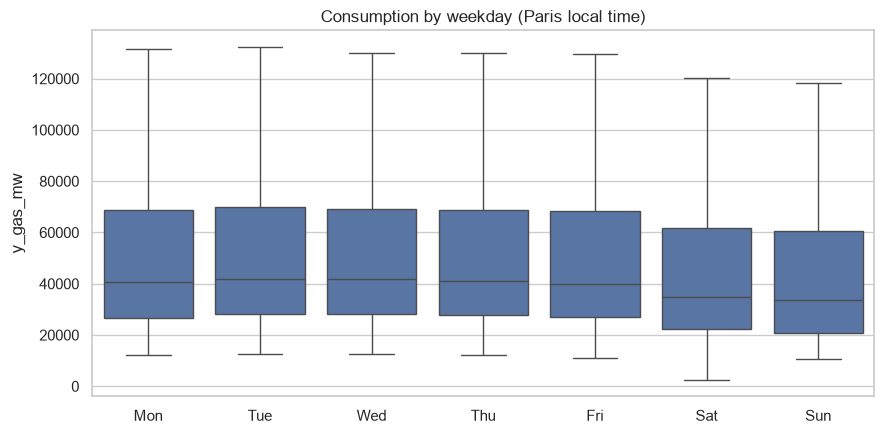

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=df, x="dow_name", y="y_gas_mw", ax=ax, showfliers=False, color="#4C72B0")
ax.set_xlabel("")
ax.set_title("Consumption by weekday (Paris local time)")
plt.tight_layout()
plt.show()

## 7. Heatmap: average consumption by hour x month
Expected: clear horizontal bands (winter high, summer low), sharper intraday profile in winter.

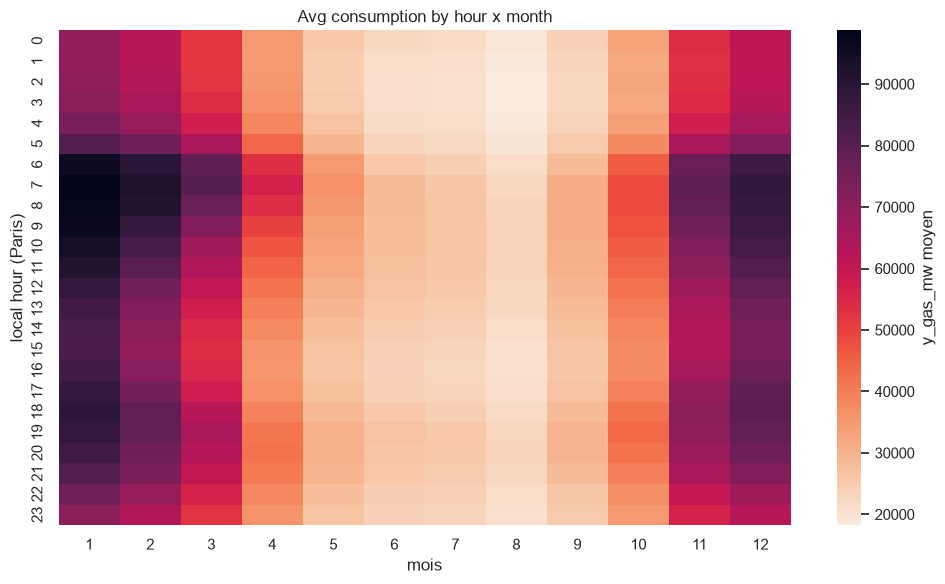

In [8]:
pivot_month = df.pivot_table(index="hour", columns="month", values="y_gas_mw", aggfunc="mean")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_month, cmap="rocket_r", ax=ax, cbar_kws={"label": "y_gas_mw moyen"})
ax.set_xlabel("mois")
ax.set_ylabel("local hour (Paris)")
ax.set_title("Avg consumption by hour x month")
plt.tight_layout()
plt.show()

## 8. Heatmap: average consumption by hour x weekday
Expected: weekday morning peak (7-9 AM) softened on weekends.

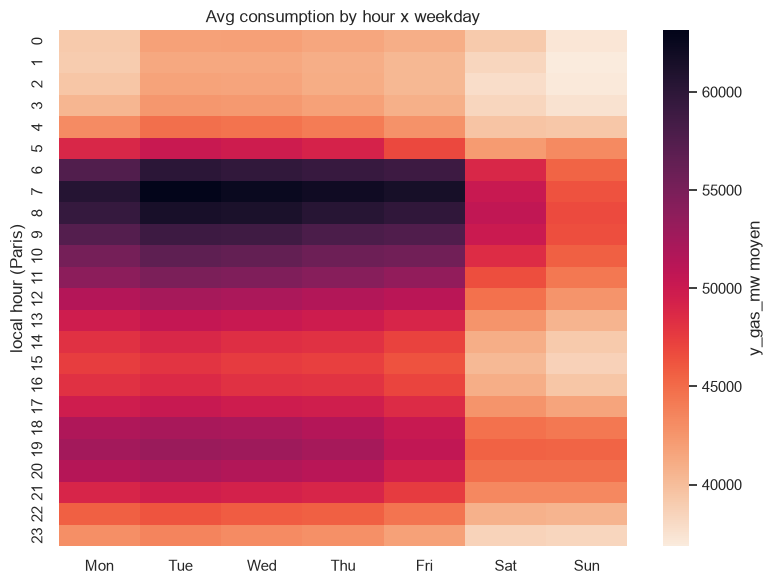

In [9]:
pivot_dow = df.pivot_table(index="hour", columns="dow_name", values="y_gas_mw", aggfunc="mean", observed=True)
pivot_dow = pivot_dow[dow_labels]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_dow, cmap="rocket_r", ax=ax, cbar_kws={"label": "y_gas_mw moyen"})
ax.set_xlabel("")
ax.set_ylabel("local hour (Paris)")
ax.set_title("Avg consumption by hour x weekday")
plt.tight_layout()
plt.show()

## 9. Correlations with the target
Overview: sign and strength of each Table 1 explanatory variable's linear correlation with `y_gas_mw` (indicative only — calendar/Fourier effects are not expected to be linear in isolation).

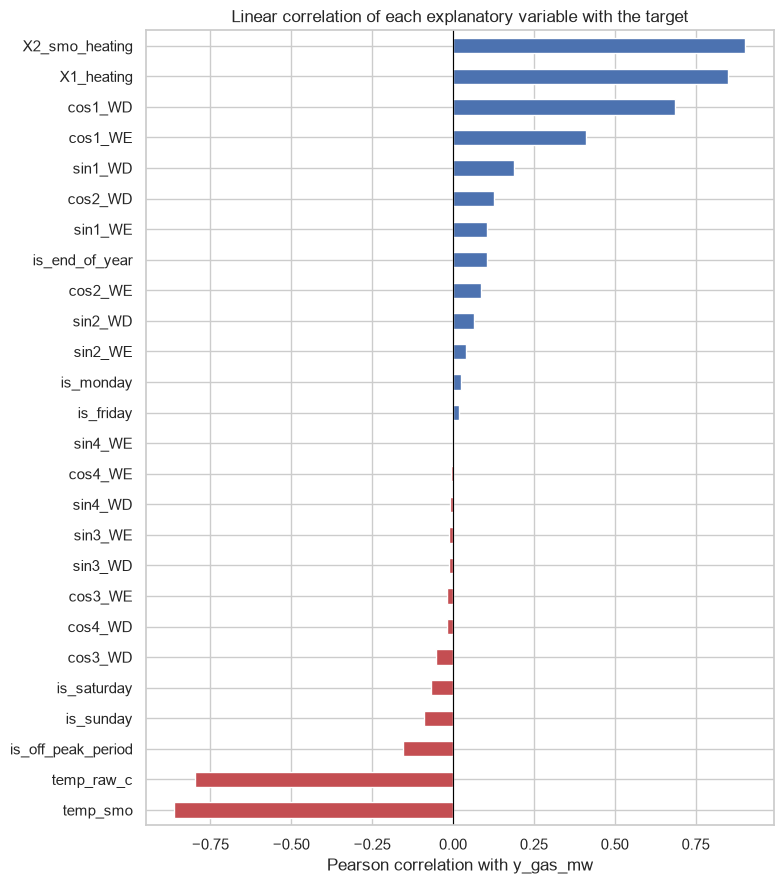

In [10]:
exclude = {"y_gas_mw", "beta_0", "month", "hour", "dow"}
num_cols = [c for c in df.select_dtypes("number").columns if c not in exclude]
corr = df[num_cols].corrwith(df["y_gas_mw"]).sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in corr.values]
corr.plot.barh(ax=ax, color=colors)
ax.set_xlabel("Pearson correlation with y_gas_mw")
ax.set_title("Linear correlation of each explanatory variable with the target")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()